## **Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score , precision_score , confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, learning_curve
from scipy.stats import skew
from sklearn.svm import SVC

## **Data Gathering**

In [ ]:
data = pd.read_csv('/content/kaggle_diabetes.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/kaggle_diabetes.csv'

In [ ]:
data

NameError: name 'data' is not defined

## **Descriptive Analysis**

In [ ]:
data.info()

NameError: name 'data' is not defined

In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [ ]:
data[data['Age']>40]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
5,0,173,78,32,265,46.5,1.159,58,0
7,8,194,80,0,0,26.1,0.551,67,0
9,2,89,90,30,0,33.5,0.292,42,0
11,4,125,70,18,122,28.9,1.144,45,1
...,...,...,...,...,...,...,...,...,...
1975,8,188,78,0,0,47.9,0.137,43,1
1980,17,163,72,41,114,40.9,0.817,47,1
1982,7,102,74,40,105,37.2,0.204,45,0
1986,6,104,74,18,156,29.9,0.722,41,1


In [ ]:
data[data['BloodPressure']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,0,145,0,0,0,44.2,0.630,31,1
12,3,80,0,0,0,0.0,0.174,22,0
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
...,...,...,...,...,...,...,...,...,...
1870,7,105,0,0,0,0.0,0.305,24,0
1881,2,84,0,0,0,0.0,0.304,21,0
1899,0,131,0,0,0,43.2,0.270,26,1
1902,2,74,0,0,0,0.0,0.102,22,0


In [ ]:
#Implace zeros in featuers that is not biologically possible with mediam

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[zero_cols] = data[zero_cols].replace(0, pd.NA)
data.fillna(data.median(), inplace=True)

/tmp/ipython-input-846521094.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.fillna(data.median(), inplace=True)


In [ ]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,126.0,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,72.0,29.0,126.0,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75.0,64.0,24.0,55.0,29.7,0.370,33,0
1996,8,179.0,72.0,42.0,130.0,32.7,0.719,36,1
1997,6,85.0,78.0,29.0,126.0,31.2,0.382,42,0
1998,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1


In [ ]:
data[data["Glucose"]<50]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
62,5,44.0,62.0,29.0,126.0,25.0,0.587,36,0
1883,5,44.0,62.0,29.0,126.0,25.0,0.587,36,0


In [ ]:
print(data['Pregnancies'].value_counts().sort_index())

Pregnancies
0     301
1     356
2     284
3     195
4     191
5     141
6     131
7     100
8      96
9      70
10     54
11     24
12     23
13     22
14      7
15      2
17      3
Name: count, dtype: int64


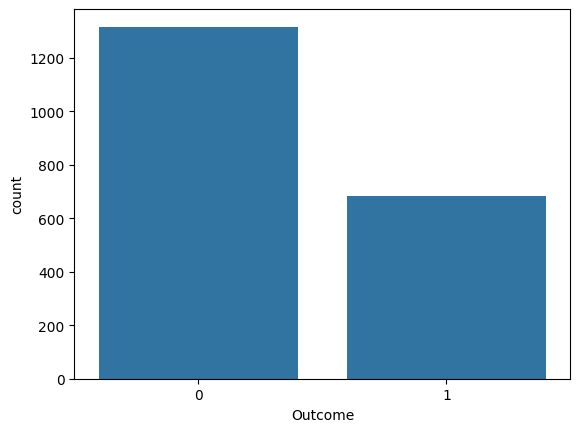

In [ ]:
sns.countplot(x='Outcome',data=data)
plt.show()

In [ ]:
data.hist(figsize=(12, 10))
plt.show()

NameError: name 'data' is not defined

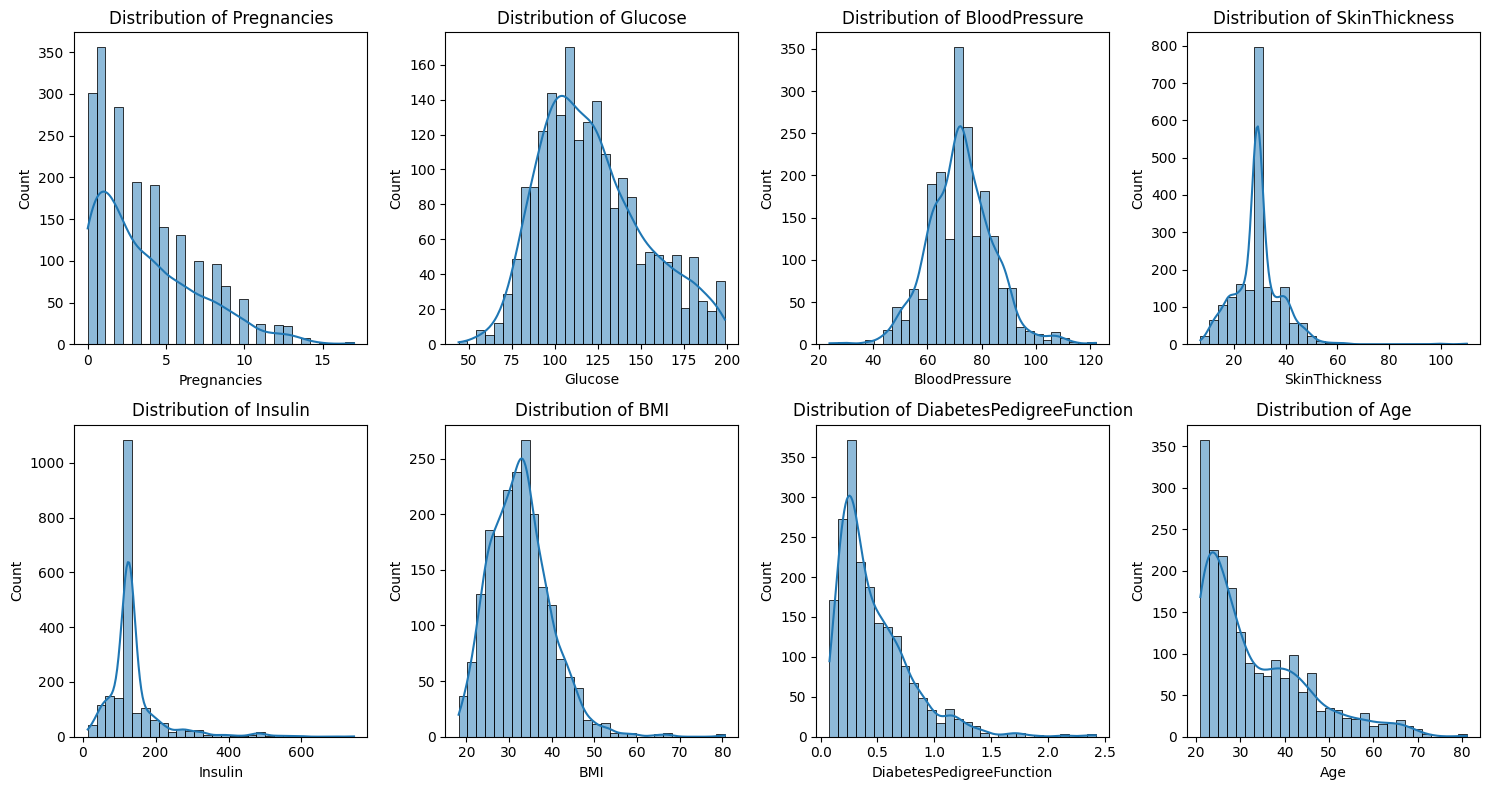

In [ ]:
# HistPlot distributions for each feature

numeric_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

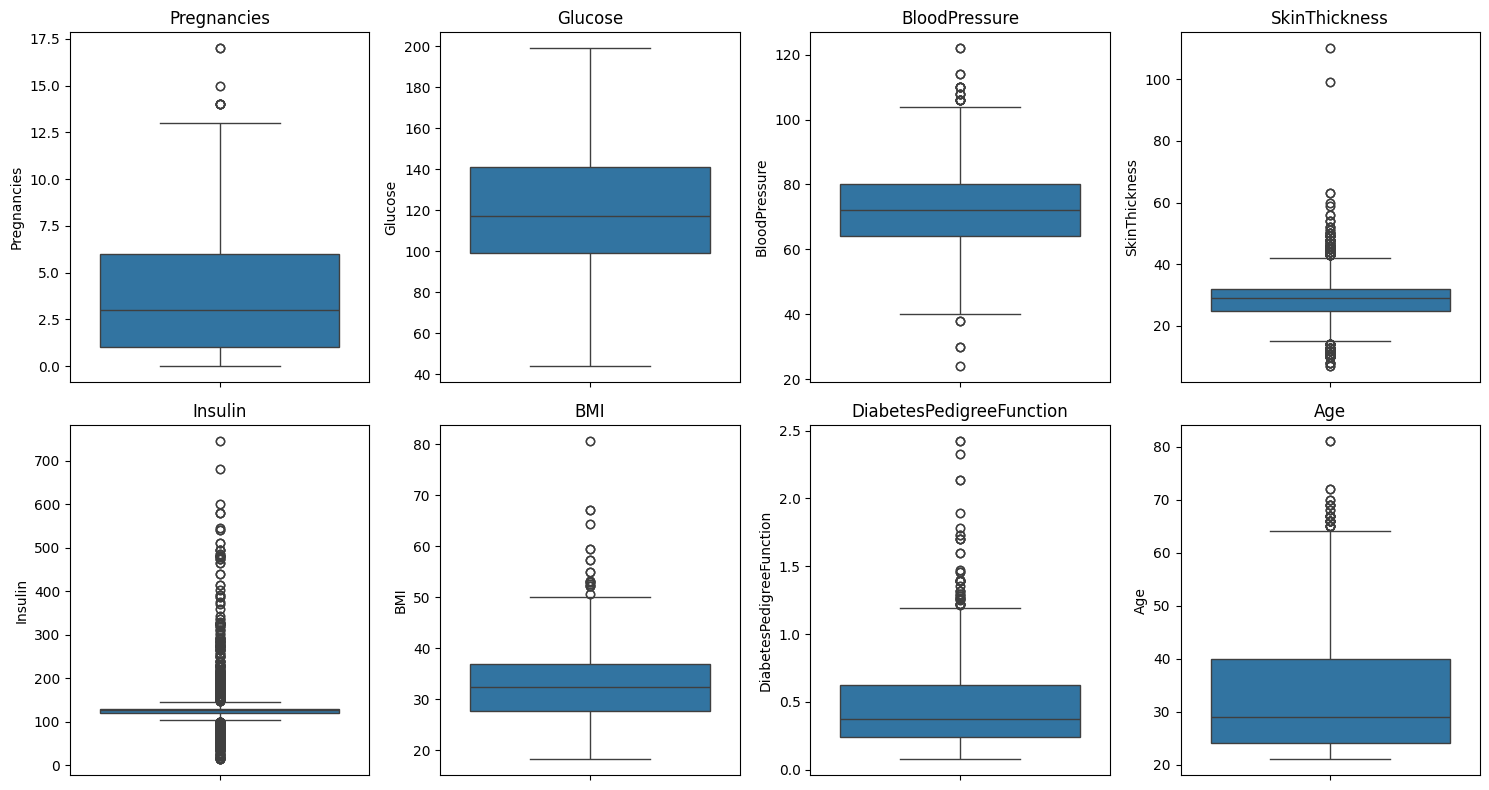

In [ ]:
# BoxPlot distributions for each feature

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [ ]:
skewness = {
    'Insulin': skew(data['Insulin']),
    'DiabetesPedigreeFunction': skew(data['DiabetesPedigreeFunction']),
    'Age': skew(data['Age']),
}
print(skewness)

{'Insulin': np.float64(2.973312283298848), 'DiabetesPedigreeFunction': np.float64(1.8106196267530008), 'Age': np.float64(1.180381087900115)}


In [ ]:
#Transforming Skewed Features

data['Insulin_log'] = np.log1p(data['Insulin'])
data['DPF_sqrt'] = np.sqrt(data['DiabetesPedigreeFunction'])

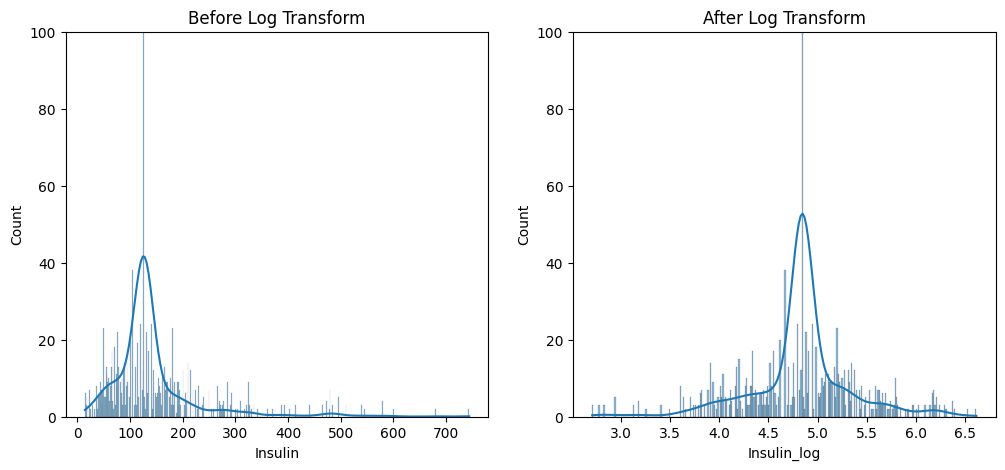

In [ ]:
#Comparison between before and after log transform in Insulin feature

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['Insulin'], kde=True)
plt.title('Before Log Transform')
plt.ylim(0, 100)

plt.subplot(1, 2, 2)
sns.histplot(data['Insulin_log'], kde=True)
plt.title('After Log Transform')
plt.ylim(0, 100)
plt.show()

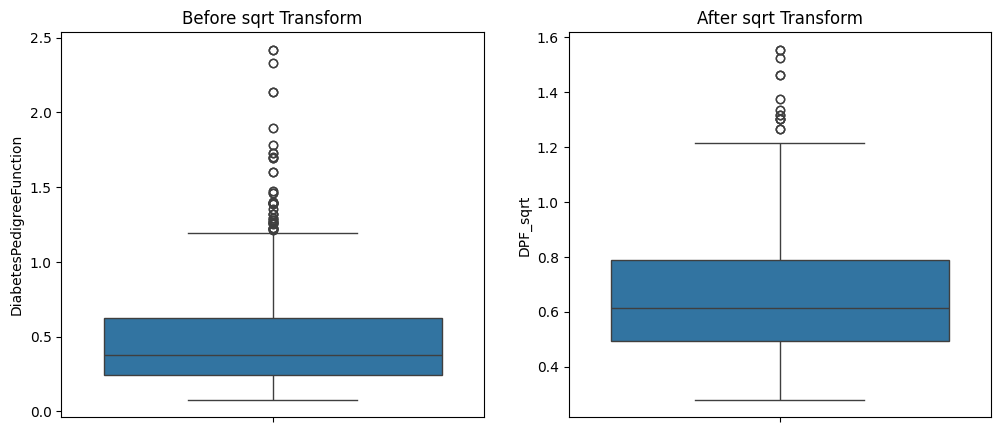

In [ ]:
#Comparison between before and after sqrt transform in Insulin feature

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data['DiabetesPedigreeFunction'])
plt.title('Before sqrt Transform')

plt.subplot(1, 2, 2)
sns.boxplot(data['DPF_sqrt'])
plt.title('After sqrt Transform')
plt.show()

In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Insulin_log,DPF_sqrt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.943000,72.385500,29.243500,140.48200,32.646600,0.470930,33.090500,0.342000,4.831104,0.652187
std,3.306063,30.535733,11.949824,9.124957,81.56284,7.190196,0.323553,11.786423,0.474498,0.489995,0.213552
min,0.000000,44.000000,24.000000,7.000000,14.00000,18.200000,0.078000,21.000000,0.000000,2.708050,0.279285
25%,1.000000,99.000000,64.000000,25.000000,120.00000,27.600000,0.244000,24.000000,0.000000,4.795791,0.493964
50%,3.000000,117.000000,72.000000,29.000000,126.00000,32.400000,0.376000,29.000000,0.000000,4.844187,0.613188
75%,6.000000,141.000000,80.000000,32.000000,130.00000,36.800000,0.624000,40.000000,1.000000,4.875197,0.789937
max,17.000000,199.000000,122.000000,110.000000,744.00000,80.600000,2.420000,81.000000,1.000000,6.613384,1.555635


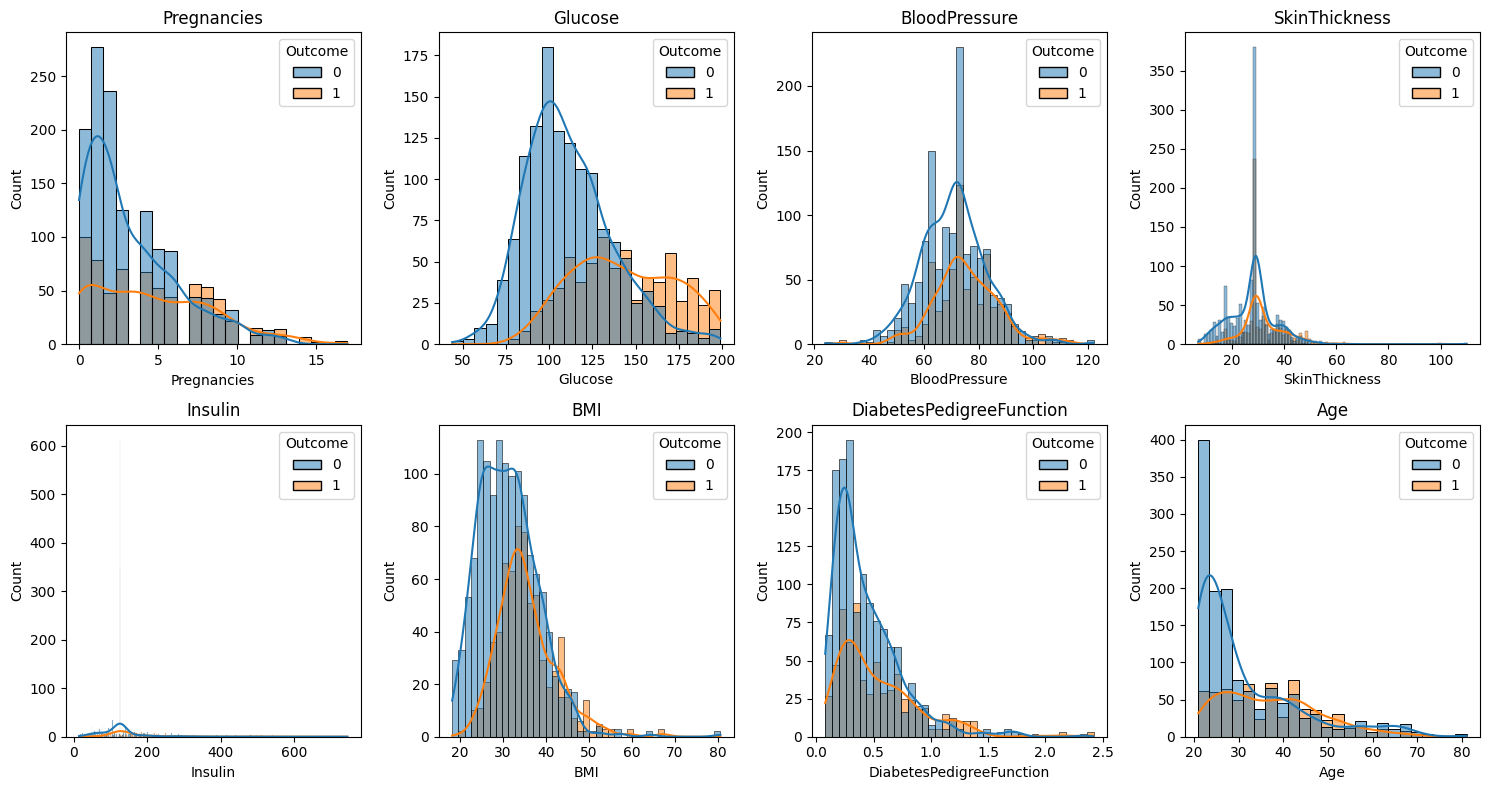

In [ ]:
#Histograms for each numeric feature separated by Outcome

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.histplot(data, x=feature, hue='Outcome', kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

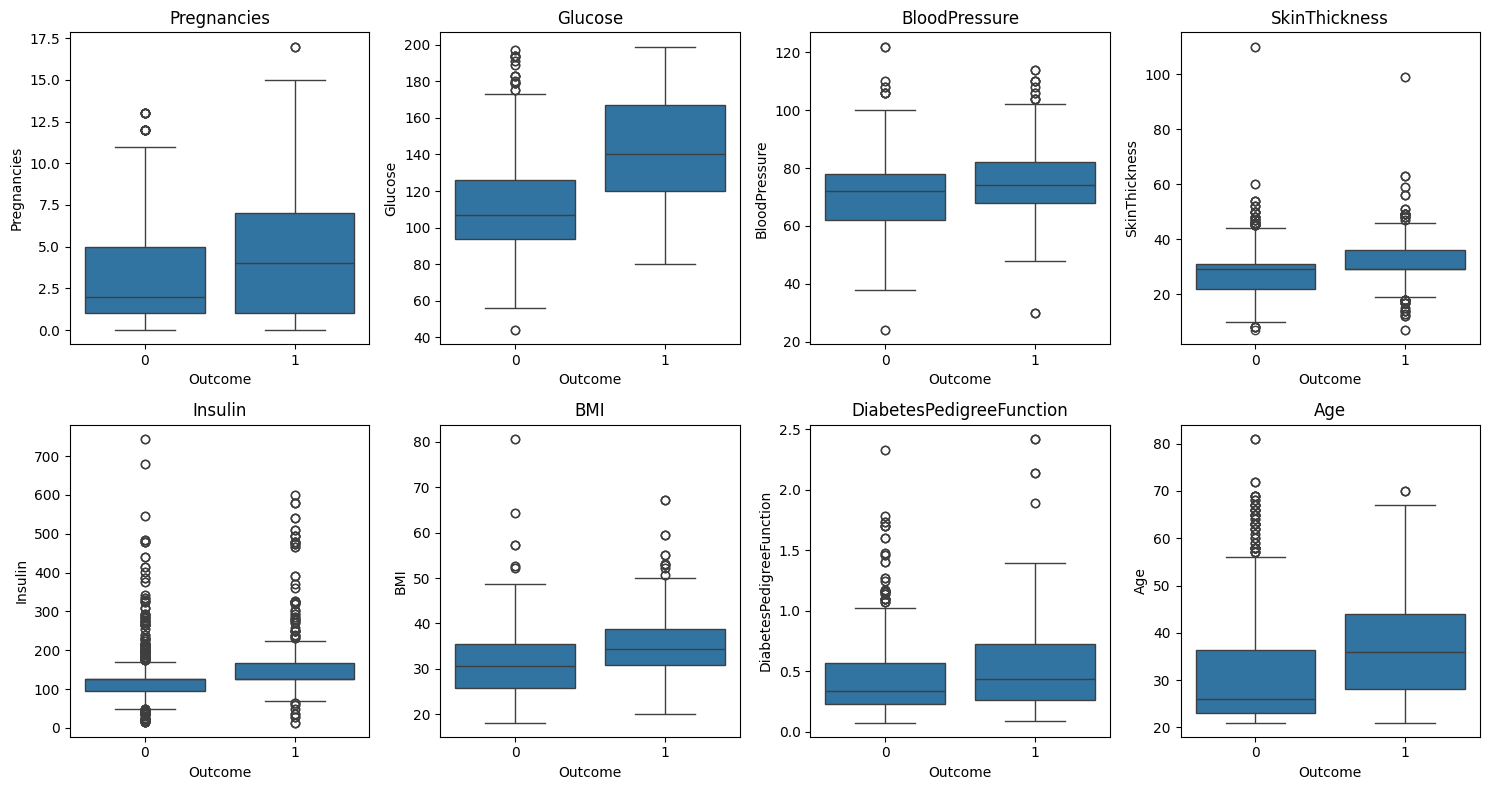

In [ ]:
#Boxplot for each numeric feature separated by Outcome

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='Outcome', y=feature, data=data)
    plt.title(feature)
plt.tight_layout()
plt.show()

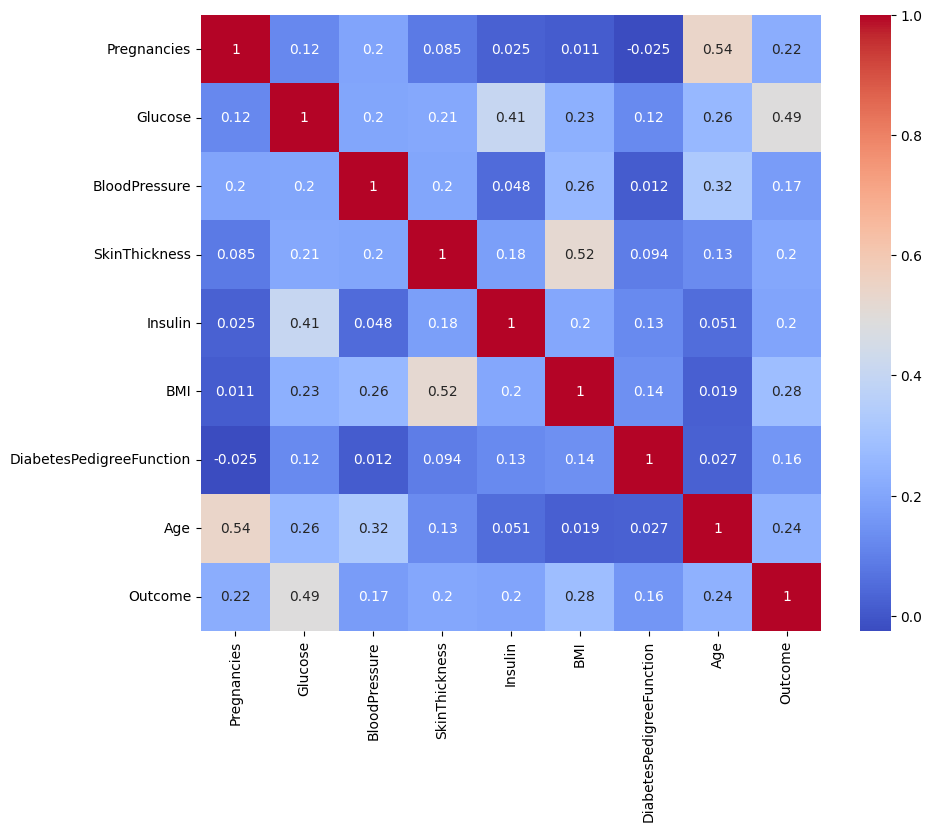

In [ ]:
#Correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

The conclusions:
1. There is a strong correlation between Glucose and Outcome
2. Patients with BMI > 30 or Age > 40 are significantly more likely to develop diabetes
3. There is skewed distributions in Insulin and DiabetesPedigreeFunction
4. The skew in Pregnancies normal because normal pregnancies is < 5
5. There is outlier in SkinThickness and Age

## **Data Modelling**

In [ ]:
#Model Preparation

x = data.drop(['Outcome','Insulin', 'DiabetesPedigreeFunction'], axis=1)
y = data['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "xgboost": XGBClassifier()
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       253
           1       0.77      0.56      0.65       147

    accuracy                           0.78       400
   macro avg       0.77      0.73      0.74       400
weighted avg       0.77      0.78      0.77       400

Decision Tree Accuracy: 0.9675
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       253
           1       0.95      0.96      0.96       147

    accuracy                           0.97       400
   macro avg       0.96      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400

Random Forest Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       253
           1       0.99      0.99      0.99       147

    accuracy                           0.99       400
   macro avg       0.99      0.9

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    class_weight="balanced"
)

scores = cross_val_score(model, x, y, cv=5)
print("Mean CV Accuracy:", scores.mean())

Mean CV Accuracy: 0.9475000000000001


In [ ]:
model.fit(X_train_scaled, y_train)
prediction = model.predict(X_test_scaled)

print("Train Accuracy:", model.score(X_train_scaled, y_train))
print("Test Accuracy:", model.score(X_test_scaled, y_test))

Train Accuracy: 0.979375
Test Accuracy: 0.9425


In [ ]:
confusion_matrix(y_test,prediction)

array([[239,  14],
       [  9, 138]])

In [ ]:
acc = accuracy_score(y_test, prediction)
prec = precision_score(y_test, prediction)
rec = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"Accuracy     : {acc:.3f}")
print(f"Precision    : {prec:.3f}")
print(f"Recall       : {rec:.3f}")
print(f"F1-score     : {f1:.3f}")

Accuracy     : 0.943
Precision    : 0.908
Recall       : 0.939
F1-score     : 0.923


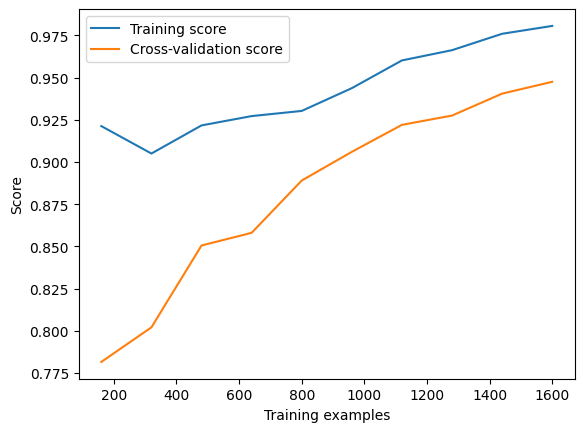